# Assignment 2 — Transfer Learning & Fine-Tuning with EfficientNet-B1
`BEFORE PROCEEDING`: read the questions in the end of the notebook first  
In the lecture notebook we walked through transfer learning and fine-tuning **ResNet-34** on
the Weather Image Recognition dataset, using three strategies:

1. **Feature extraction** — freeze the backbone, train only the classification head.
2. **Partial fine-tuning** — unfreeze a small number of later layers, with a differential
   (smaller) learning rate for the backbone vs. the head.
3. **Full fine-tuning** — unfreeze the entire network, with differential learning rates
   increasing from the earliest layers to the head.

Your task in this assignment is to repeat the same experiment on a **different architecture:
EfficientNet-B1**. The dataset loading, splitting, and the reusable training loop are already
provided for you — your job is to fill in the parts marked `# TODO`.

## What you need to do
- Build an EfficientNet-B1-based classifier (replace its classification head).
- Implement Stage 1 (feature extraction), Stage 2 (partial fine-tuning), and Stage 3 (full
  fine-tuning) — each cell tells you exactly what to freeze/unfreeze and what to set up.
- Implement the evaluation function (accuracy, precision, recall, F1-score).
- **Experiment with different learning rates** for Stages 2 and 3 and record what you observe
  in the markdown discussion cells provided at the end.

## What's already done for you
- Dataset scanning, stratified train/val/test split, class-imbalance handling.
- The custom `Dataset` class and transforms.
- Visualizing EfficientNet-B1's first convolutional filters before/after loading pretrained
  weights (same idea as the ResNet-34 `conv1` visualization from lecture).
- The generic `train_model` / `plot_history` training-loop helpers — you do **not** need to
  rewrite the training loop, just call it correctly with the right model/optimizer for each
  stage.

## A few pointers on EfficientNet's architecture (read before you start)

`torchvision.models.efficientnet_b1(...)` is structured differently from ResNet:

- `model.features` is a single `nn.Sequential` containing the stem convolution
  (`model.features[0]`) followed by 7 groups of MBConv blocks (`model.features[1]` through
  `model.features[7]`), followed by a final 1x1 "head" convolution (`model.features[8]`).
- `model.classifier` is a small `nn.Sequential(Dropout, Linear(in_features, 1000))` — this is
  the equivalent of ResNet's single `model.fc` layer, and it's what you need to replace for our
  `NUM_CLASSES`.
- There is no single `model.conv1` like ResNet — the very first conv layer lives at
  `model.features[0][0]`.

Keep this structure in mind: whenever the lecture notebook referenced `model.fc`,
`model.layer4`, etc., you'll need the EfficientNet equivalents (`model.classifier`,
`model.features[7]`, etc.).

> **Before you run this notebook:** update `DATA_DIR` in the *Configuration* cell to point to
> your dataset folder (same structure as before: one sub-folder per class).


## 1. Imports & reproducibility (provided)

Same setup as the lecture notebook. Nothing to change here.

In [29]:
import os
import copy
import time
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import transforms, models
from torchvision.models import EfficientNet_B1_Weights

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"PyTorch version:     {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")
print(f"Using device:        {device}")


PyTorch version:     2.10.0+cu128
Torchvision version: 0.25.0+cu128
Using device:        cuda


## 2. Configuration (provided)

`DATA_DIR` must point to a folder with one sub-folder per class. `IMG_SIZE` is set to `240`,
EfficientNet-B1's native training resolution (each EfficientNet variant is designed around a
specific input resolution — B0 uses 224, B1 uses 240, B2 uses 260, and so on — using the wrong
resolution won't break the code, but it does hurt accuracy).

In [13]:
# --- EDIT THIS to match your environment ---
DATA_DIR = "/kaggle/input/datasets/jehanbhathena/weather-dataset/dataset"
IMG_SIZE = 240        # EfficientNet-B1's native resolution
BATCH_SIZE = 32
NUM_WORKERS = 2


## 3. Scanning the dataset & checking for class imbalance (provided)

Identical to the lecture notebook: build a DataFrame of `(filepath, label)` pairs by reading
class names directly from the folder structure, then visualize the class distribution.

In [14]:
CLASSES = sorted(
    d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))
)
NUM_CLASSES = len(CLASSES)
class_to_idx = {c: i for i, c in enumerate(CLASSES)}
idx_to_class = {i: c for c, i in class_to_idx.items()}

print(f"Found {NUM_CLASSES} classes:")
for c in CLASSES:
    print(f"  - {c}")

VALID_EXTENSIONS = (".jpg", ".jpeg", ".png")

records = []
for c in CLASSES:
    class_dir = os.path.join(DATA_DIR, c)
    for fname in os.listdir(class_dir):
        if fname.lower().endswith(VALID_EXTENSIONS):
            records.append({"filepath": os.path.join(class_dir, fname), "label": c})

df = pd.DataFrame(records)
print(f"\nTotal images found: {len(df)}")
df.head()


Found 11 classes:
  - dew
  - fogsmog
  - frost
  - glaze
  - hail
  - lightning
  - rain
  - rainbow
  - rime
  - sandstorm
  - snow

Total images found: 6862


,filepath,label
0,/kaggle/input/datasets/jehanbhathena/weather-d...,dew
1,/kaggle/input/datasets/jehanbhathena/weather-d...,dew
2,/kaggle/input/datasets/jehanbhathena/weather-d...,dew
3,/kaggle/input/datasets/jehanbhathena/weather-d...,dew
4,/kaggle/input/datasets/jehanbhathena/weather-d...,dew


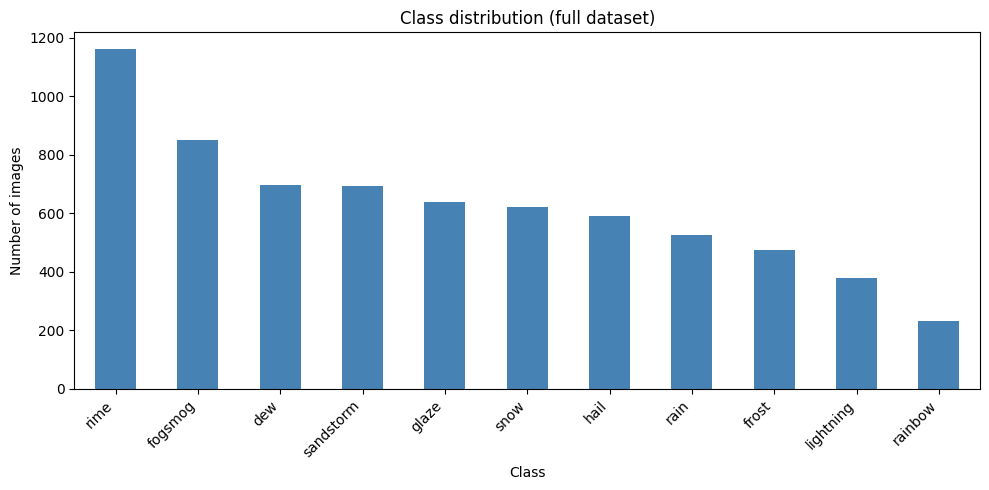

label
rime         1160
fogsmog       851
dew           698
sandstorm     692
glaze         639
snow          621
hail          591
rain          526
frost         475
lightning     377
rainbow       232
Name: count, dtype: int64

Imbalance ratio (largest class / smallest class): 5.00x


In [15]:
class_counts = df["label"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
class_counts.plot(kind="bar", color="steelblue")
plt.title("Class distribution (full dataset)")
plt.xlabel("Class")
plt.ylabel("Number of images")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print(class_counts)
imbalance_ratio = class_counts.max() / class_counts.min()
print(f"\nImbalance ratio (largest class / smallest class): {imbalance_ratio:.2f}x")


## 4. Stratified train / validation / test split (provided)

Same 70/15/15 stratified split as the lecture, so every split preserves the original class
proportions despite the imbalance.

In [16]:
train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df["label"], random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["label"], random_state=SEED
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Train: {len(train_df)} images ({len(train_df) / len(df):.1%})")
print(f"Val:   {len(val_df)} images ({len(val_df) / len(df):.1%})")
print(f"Test:  {len(test_df)} images ({len(test_df) / len(df):.1%})")


Train: 4803 images (70.0%)
Val:   1029 images (15.0%)
Test:  1030 images (15.0%)


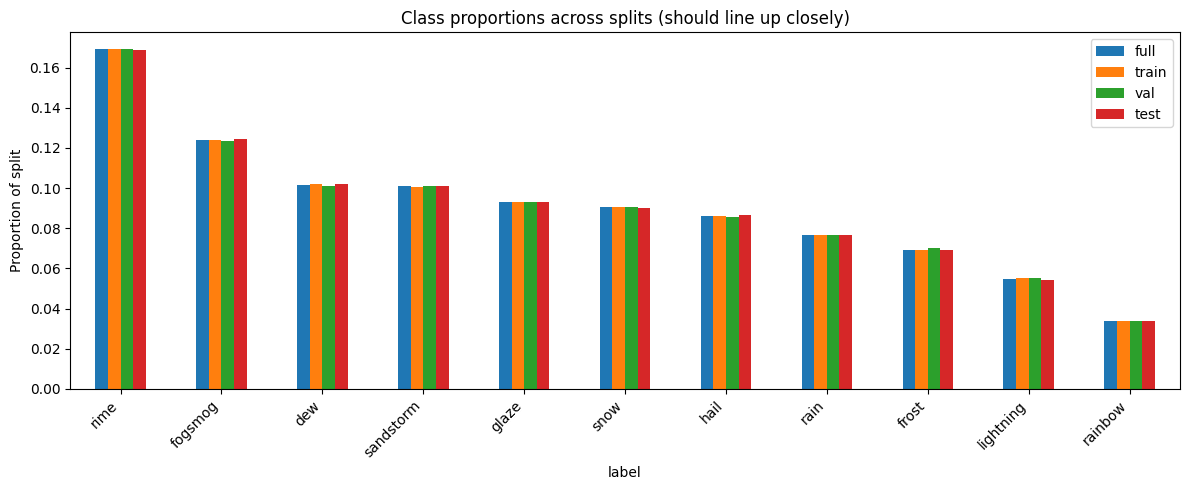

,full,train,val,test
label,,,,
rime,0.169,0.169,0.169,0.169
fogsmog,0.124,0.124,0.123,0.124
dew,0.102,0.102,0.101,0.102
sandstorm,0.101,0.101,0.101,0.101
glaze,0.093,0.093,0.093,0.093
snow,0.090,0.091,0.090,0.090
hail,0.086,0.086,0.086,0.086
rain,0.077,0.077,0.077,0.077
frost,0.069,0.069,0.070,0.069


In [17]:
proportions = pd.DataFrame({
    "full": df["label"].value_counts(normalize=True),
    "train": train_df["label"].value_counts(normalize=True),
    "val": val_df["label"].value_counts(normalize=True),
    "test": test_df["label"].value_counts(normalize=True),
}).sort_values("full", ascending=False)

proportions.plot(kind="bar", figsize=(12, 5))
plt.title("Class proportions across splits (should line up closely)")
plt.ylabel("Proportion of split")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

proportions.round(3)


## 5. Dataset class & transforms (provided)

Same `WeatherDataset` class as lecture. Transforms use ImageNet mean/std (required since we're
using ImageNet-pretrained weights) at `IMG_SIZE=240`, with light augmentation for training only.
Class weights are computed the same way, for the same reason: to counteract class imbalance in
the loss function.

In [18]:
class WeatherDataset(Dataset):
    def __init__(self, dataframe, class_to_idx, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.class_to_idx = class_to_idx
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image = Image.open(row["filepath"]).convert("RGB")
        label = self.class_to_idx[row["label"]]

        if self.transform is not None:
            image = self.transform(image)

        return image, label


In [21]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize(int(IMG_SIZE * 1.14)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_dataset = WeatherDataset(train_df, class_to_idx, transform=train_transform)
val_dataset = WeatherDataset(val_df, class_to_idx, transform=eval_transform) #TODO: Complete this line
test_dataset = WeatherDataset(test_df, class_to_idx, transform=eval_transform) #TODO: Complete this line

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=NUM_WORKERS, pin_memory=True)
val_loader =  DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
) #TODO: Complete this line

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
) #TODO: Complete this line

dataloaders = {"train": train_loader, "val": val_loader}
dataset_sizes = {"train": len(train_dataset), "val": len(val_dataset)}

print(f"Train batches: {len(train_loader)}  Val batches: {len(val_loader)}  "
      f"Test batches: {len(test_loader)}")


Train batches: 151  Val batches: 33  Test batches: 33


In [22]:
class_sample_counts = train_df["label"].value_counts().reindex(CLASSES).values
class_weights = 1.0 / class_sample_counts
class_weights = class_weights / class_weights.sum() * NUM_CLASSES
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

print(f"{'Class':12s} {'#train imgs':>12s} {'loss weight':>12s}")
for c, n, w in zip(CLASSES, class_sample_counts, class_weights):
    print(f"{c:12s} {n:12d} {w:12.3f}")


Class         #train imgs  loss weight
dew                   489        0.758
fogsmog               596        0.622
frost                 332        1.117
glaze                 447        0.830
hail                  414        0.896
lightning             264        1.405
rain                  368        1.008
rainbow               162        2.289
rime                  812        0.457
sandstorm             484        0.766
snow                  435        0.853


## 6. Visualizing EfficientNet-B1's first conv layer before/after pretraining (provided)

Same idea as the ResNet-34 `conv1` visualization in lecture, adapted for EfficientNet: the very
first convolution lives at `model.features[0][0]` (a `3x3` conv, smaller than ResNet's `7x7`, so
the filters will look tinier). Compare the random-init vs. ImageNet-pretrained filters — you
should still see the pretrained ones look more structured.

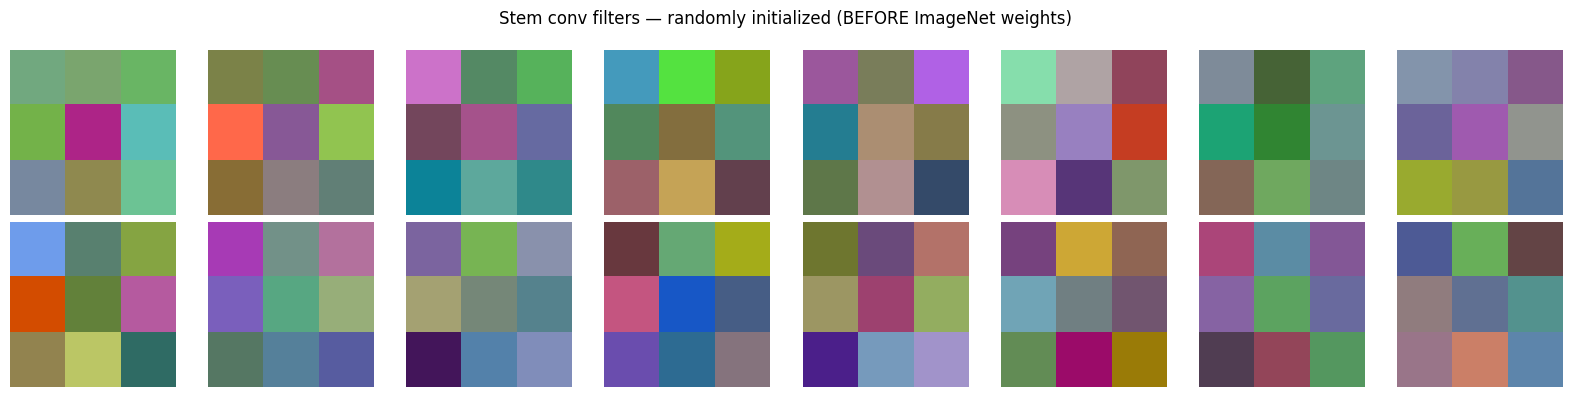

Downloading: "https://download.pytorch.org/models/efficientnet_b1-c27df63c.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b1-c27df63c.pth


100%|██████████| 30.1M/30.1M [00:00<00:00, 122MB/s] 


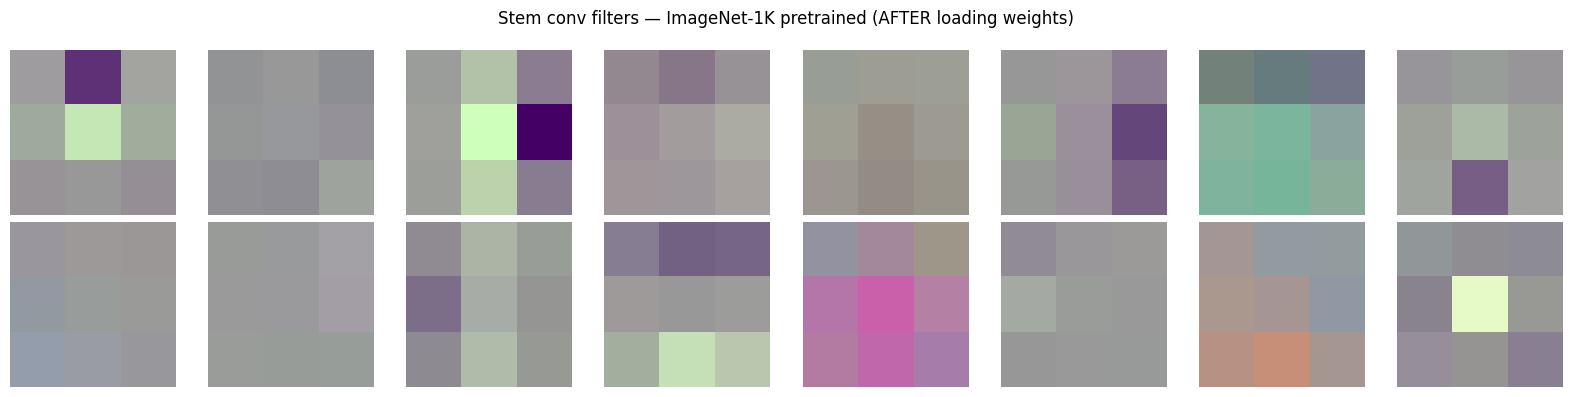

In [23]:
def get_stem_conv_weights(model):
    return model.features[0][0].weight.data.clone().cpu()


def visualize_filters(weights, title, n_filters=16):
    w = weights[:n_filters].clone()
    w_min, w_max = w.min(), w.max()
    w = (w - w_min) / (w_max - w_min + 1e-8)

    n_cols = 8
    n_rows = int(np.ceil(n_filters / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(2 * n_cols, 2 * n_rows))
    fig.suptitle(title)
    for i, ax in enumerate(axes.flat):
        if i < w.shape[0]:
            img = w[i].permute(1, 2, 0).numpy()
            ax.imshow(img)
        ax.axis("off")
    plt.tight_layout()
    plt.show()


model_random = models.efficientnet_b1(weights=None)
stem_random = get_stem_conv_weights(model_random)
visualize_filters(stem_random, "Stem conv filters \u2014 randomly initialized (BEFORE ImageNet weights)")

model_pretrained = models.efficientnet_b1(weights=models.EfficientNet_B1_Weights.IMAGENET1K_V2)
stem_pretrained = get_stem_conv_weights(model_pretrained)
visualize_filters(stem_pretrained, "Stem conv filters \u2014 ImageNet-1K pretrained (AFTER loading weights)")

del model_random, model_pretrained


## 7. Generic training loop (provided)

This is the exact same `train_model` / `plot_history` pair from lecture — it doesn't care what
architecture you pass in, only that `model`, `criterion`, and `optimizer` are set up correctly.
You will call this function, unmodified, from each of the three stages below.

In [24]:
def train_model(model, dataloaders, dataset_sizes, criterion, optimizer,
                 scheduler=None, num_epochs=5, stage_name="stage"):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_acc = 0.0
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(num_epochs):
        print(f"\n[{stage_name}] Epoch {epoch + 1}/{num_epochs}")
        print("-" * 40)

        for phase in ["train", "val"]:
            model.train() if phase == "train" else model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == "train"):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == "train":
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            if phase == "train" and scheduler is not None:
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = (running_corrects.double() / dataset_sizes[phase]).item()

            history[f"{phase}_loss"].append(epoch_loss)
            history[f"{phase}_acc"].append(epoch_acc)

            print(f"{phase:5s} | loss: {epoch_loss:.4f}  acc: {epoch_acc:.4f}")

            if phase == "val" and epoch_acc > best_val_acc:
                best_val_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

    elapsed = time.time() - since
    print(f"\n[{stage_name}] Training complete in {elapsed // 60:.0f}m {elapsed % 60:.0f}s")
    print(f"[{stage_name}] Best validation accuracy: {best_val_acc:.4f}")

    model.load_state_dict(best_model_wts)
    return model, history


def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history["train_loss"], label="train", marker="o")
    axes[0].plot(history["val_loss"], label="val", marker="o")
    axes[0].set_title(f"{title} \u2014 Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(history["train_acc"], label="train", marker="o")
    axes[1].plot(history["val_acc"], label="val", marker="o")
    axes[1].set_title(f"{title} \u2014 Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


## 8. TODO: build your EfficientNet-B1 model

Write a function `build_efficientnet_b1(num_classes, pretrained=True)` that:
- Loads `torchvision.models.efficientnet_b1` with `EfficientNet_B1_Weights.IMAGENET1K_V2` when
  `pretrained=True`, or `weights=None` when `pretrained=False`.
- Replaces the classification head so it outputs `num_classes` instead of 1000. Remember
  `model.classifier` is `Sequential(Dropout(p), Linear(in_features, 1000))` — you need to
  replace the `Linear` layer (index `1`) with a new one, keeping the same `in_features` and the
  same dropout probability `p`. You can read `in_features` off the existing `Linear` layer
  rather than hardcoding it.
- Returns the model.

This is the EfficientNet equivalent of the `build_resnet34` helper from lecture.

In [25]:
# TODO: define build_efficientnet_b1(num_classes, pretrained=True)
#   1. weights = EfficientNet_B1_Weights.IMAGENET1K_V2 if pretrained else None
#   2. model = models.efficientnet_b1(weights=weights)
#   3. read in_features and dropout p off model.classifier[1] / model.classifier[0]
#   4. replace model.classifier[1] with a new nn.Linear(in_features, num_classes)
#   5. return model
def build_efficientnet_b1(num_classes, pretrained=True):
    weights = EfficientNet_B1_Weights.IMAGENET1K_V2 if pretrained else None

    model = models.efficientnet_b1(weights=weights)

    in_features = model.classifier[1].in_features
    dropout_p = model.classifier[0].p

    model.classifier[1] = nn.Linear(in_features, num_classes)

    return model

## 9. TODO: evaluation function

Write `evaluate_model(model, dataloader, class_names, title="Evaluation")` that mirrors the one
from lecture:
- Runs the model in `eval()` mode over `dataloader` with `torch.no_grad()`.
- Collects predictions and true labels.
- Computes **accuracy**, and **macro-averaged precision, recall, and F1-score** using
  `sklearn.metrics` (use `average="macro", zero_division=0"` — macro averaging matters here
  because our classes are imbalanced, so we don't want good performance on common classes to
  hide poor performance on rare ones).
- Prints a full `classification_report`.
- Plots a confusion matrix heatmap (`seaborn.heatmap` with `annot=True, fmt="d"`).
- Returns a dict: `{"accuracy": ..., "precision": ..., "recall": ..., "f1": ...}` — you'll need
  this exact shape later for the final comparison table.

In [34]:
def evaluate_model(model, dataloader, class_names, title="Evaluation"):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)

    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    print(f"{title}")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-score:  {f1:.4f}")

    print("\nClassification Report:")
    print(
        classification_report(
            all_labels,
            all_preds,
            target_names=class_names,
            zero_division=0
        )
    )

    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.title(f"{title} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

## 10. TODO — Stage 1: Feature extraction (head only)

Reminder of the recipe from lecture, applied to EfficientNet-B1:
- Build a pretrained model with `build_efficientnet_b1(NUM_CLASSES, pretrained=True)`.
- Freeze **every** parameter except `model.classifier` (loop over `model.named_parameters()`
  and set `requires_grad` based on whether `"classifier"` is in the parameter name).
- Move the model to `device`.
- Loss: `nn.CrossEntropyLoss(weight=class_weights_tensor)` (already defined above).
- Optimizer: `optim.Adam(model.classifier.parameters(), lr=...)` — pick a learning rate (try
  `1e-3` as a starting point, same as lecture).
- Call `train_model(...)` with a small number of epochs (e.g. `5`), then `plot_history(...)`.

Store the trained model as `model_stage1` and its history as `history_stage1` — later cells
depend on these exact names.


[Stage 1 - head only] Epoch 1/5
----------------------------------------
train | loss: 1.4260  acc: 0.7381
val   | loss: 0.9345  acc: 0.8105

[Stage 1 - head only] Epoch 2/5
----------------------------------------
train | loss: 0.7606  acc: 0.8249
val   | loss: 0.6599  acc: 0.8465

[Stage 1 - head only] Epoch 3/5
----------------------------------------
train | loss: 0.5836  acc: 0.8463
val   | loss: 0.5625  acc: 0.8484

[Stage 1 - head only] Epoch 4/5
----------------------------------------
train | loss: 0.5148  acc: 0.8534
val   | loss: 0.5130  acc: 0.8523

[Stage 1 - head only] Epoch 5/5
----------------------------------------
train | loss: 0.4534  acc: 0.8663
val   | loss: 0.4535  acc: 0.8678

[Stage 1 - head only] Training complete in 2m 52s
[Stage 1 - head only] Best validation accuracy: 0.8678


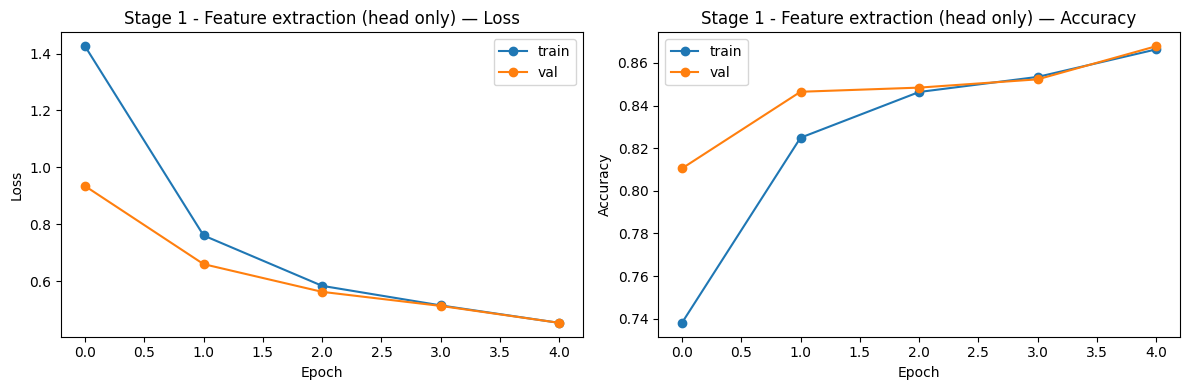

In [35]:
# TODO: Stage 1 - feature extraction
#   1. model_stage1 = build_efficientnet_b1(NUM_CLASSES, pretrained=True)
#   2. freeze every parameter except those belonging to model_stage1.classifier
#   3. model_stage1 = model_stage1.to(device)
#   4. criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
#   5. optimizer_stage1 = optim.Adam(model_stage1.classifier.parameters(), lr=<your choice>)
#   6. EPOCHS_STAGE1 = <your choice, e.g. 5>
#   7. model_stage1, history_stage1 = train_model(model_stage1, dataloaders, dataset_sizes,
#        criterion, optimizer_stage1, scheduler=None, num_epochs=EPOCHS_STAGE1,
#        stage_name="Stage 1 - head only")
#   8. plot_history(history_stage1, "Stage 1 - Feature extraction (head only)")
# Stage 1 - feature extraction

# Stage 1 - feature extraction

model_stage1 = build_efficientnet_b1(NUM_CLASSES, pretrained=True)

for name, param in model_stage1.named_parameters():
    param.requires_grad = "classifier" in name

model_stage1 = model_stage1.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

optimizer_stage1 = optim.Adam(
    model_stage1.classifier.parameters(),
    lr=1e-3
)

EPOCHS_STAGE1 = 5

model_stage1, history_stage1 = train_model(
    model_stage1,
    dataloaders,
    dataset_sizes,
    criterion,
    optimizer_stage1,
    scheduler=None,
    num_epochs=EPOCHS_STAGE1,
    stage_name="Stage 1 - head only"
)

plot_history(
    history_stage1,
    "Stage 1 - Feature extraction (head only)"
)

Stage 1 - Head only (Test set)
Accuracy:  0.8913
Precision: 0.8890
Recall:    0.8984
F1-score:  0.8929

Classification Report:
              precision    recall  f1-score   support

         dew       0.95      0.93      0.94       105
     fogsmog       0.87      0.93      0.90       128
       frost       0.78      0.86      0.82        71
       glaze       0.79      0.80      0.80        96
        hail       0.91      0.96      0.93        89
   lightning       0.98      0.98      0.98        56
        rain       0.89      0.85      0.87        79
     rainbow       0.87      0.97      0.92        35
        rime       0.94      0.86      0.90       174
   sandstorm       0.95      0.93      0.94       104
        snow       0.83      0.81      0.82        93

    accuracy                           0.89      1030
   macro avg       0.89      0.90      0.89      1030
weighted avg       0.89      0.89      0.89      1030



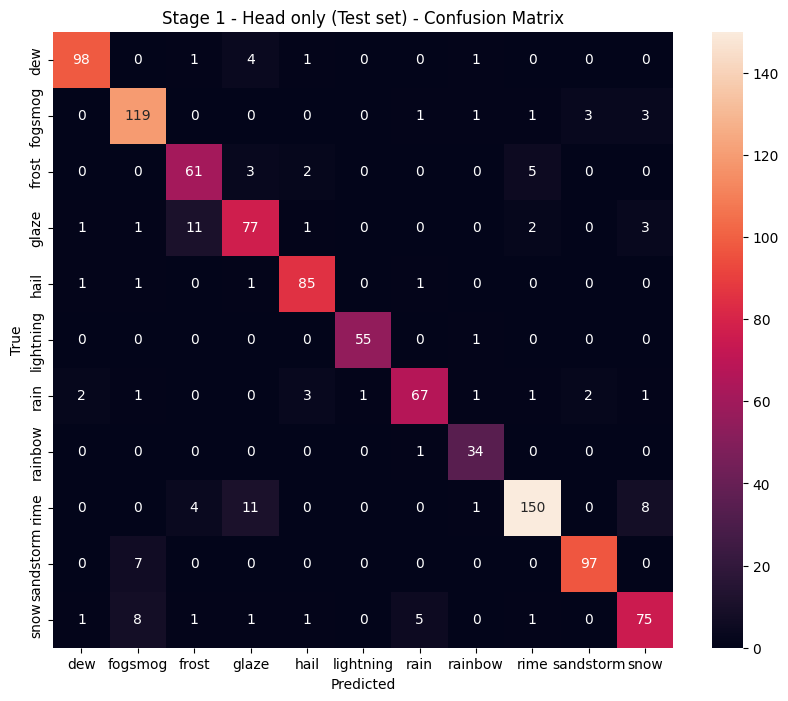

In [36]:
# TODO: evaluate Stage 1 on the test set
#   results_stage1 = evaluate_model(model_stage1, test_loader, CLASSES,
#                                    title="Stage 1 - Head only (Test set)")
results_stage1 = evaluate_model(
    model_stage1,
    test_loader,
    CLASSES,
    title="Stage 1 - Head only (Test set)"
)

## 11. TODO — Stage 2: Partial fine-tuning with differential learning rates

EfficientNet-B1's `model.features` has 9 entries: `features[0]` (stem), `features[1]` through
`features[7]` (the 7 MBConv stage groups), and `features[8]` (final 1x1 head conv). For partial
fine-tuning, unfreeze just the **last** stage group plus the head conv and classifier — e.g.
`model.features[7]`, `model.features[8]`, and `model.classifier` — and keep everything before
that frozen.

Set up an optimizer with **two parameter groups**, like lecture did with `layer4` vs `fc`:
- A small learning rate for `model.features[7]` / `model.features[8]`.
- A larger learning rate for `model.classifier`.

**This is where you should experiment.** Try at least two or three different learning-rate
combinations (e.g. backbone `1e-5` vs `1e-4`, head `1e-3` vs `5e-4`) and note what changes in
the discussion cell at the end of the notebook.

Store the trained model as `model_stage2` and its history as `history_stage2`.


[Stage 2 - Partial fine-tuning] Epoch 1/5
----------------------------------------
train | loss: 1.2965  acc: 0.7391
val   | loss: 0.7358  acc: 0.8367

[Stage 2 - Partial fine-tuning] Epoch 2/5
----------------------------------------
train | loss: 0.5794  acc: 0.8386
val   | loss: 0.5081  acc: 0.8562

[Stage 2 - Partial fine-tuning] Epoch 3/5
----------------------------------------
train | loss: 0.4417  acc: 0.8576
val   | loss: 0.4258  acc: 0.8698

[Stage 2 - Partial fine-tuning] Epoch 4/5
----------------------------------------
train | loss: 0.3816  acc: 0.8711
val   | loss: 0.3804  acc: 0.8824

[Stage 2 - Partial fine-tuning] Epoch 5/5
----------------------------------------
train | loss: 0.3505  acc: 0.8776
val   | loss: 0.3581  acc: 0.8776

[Stage 2 - Partial fine-tuning] Training complete in 2m 52s
[Stage 2 - Partial fine-tuning] Best validation accuracy: 0.8824


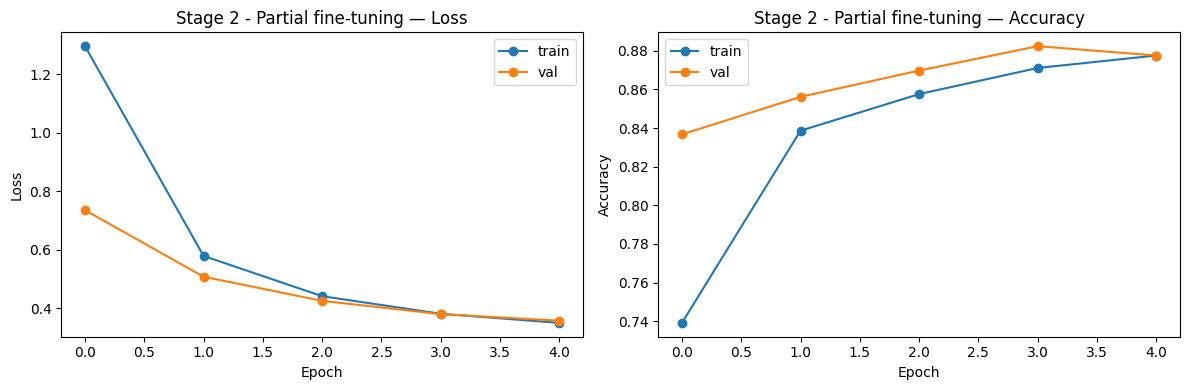

In [37]:
# TODO: Stage 2 - partial fine-tuning
#   1. model_stage2 = build_efficientnet_b1(NUM_CLASSES, pretrained=True)
#   2. freeze all parameters, then unfreeze model_stage2.features[7], features[8], and classifier
#   3. model_stage2 = model_stage2.to(device)
#   4. optimizer_stage2 = optim.Adam([
#          {"params": <features[7] + features[8] params>, "lr": <small LR, e.g. 1e-5>},
#          {"params": model_stage2.classifier.parameters(), "lr": <larger LR, e.g. 1e-3>},
#      ])
#   5. EPOCHS_STAGE2 = <your choice>
#   6. model_stage2, history_stage2 = train_model(...)
#   7. plot_history(history_stage2, "Stage 2 - Partial fine-tuning")
# Stage 2 - Partial fine-tuning

model_stage2 = build_efficientnet_b1(NUM_CLASSES, pretrained=True)

# Freeze all parameters first
for param in model_stage2.parameters():
    param.requires_grad = False

# Unfreeze features[7]
for param in model_stage2.features[7].parameters():
    param.requires_grad = True

# Unfreeze features[8]
for param in model_stage2.features[8].parameters():
    param.requires_grad = True

# Unfreeze classifier
for param in model_stage2.classifier.parameters():
    param.requires_grad = True

model_stage2 = model_stage2.to(device)

optimizer_stage2 = optim.Adam([
    {
        "params": list(model_stage2.features[7].parameters()) +
                  list(model_stage2.features[8].parameters()),
        "lr": 1e-5
    },
    {
        "params": model_stage2.classifier.parameters(),
        "lr": 1e-3
    }
])

EPOCHS_STAGE2 = 5

model_stage2, history_stage2 = train_model(
    model_stage2,
    dataloaders,
    dataset_sizes,
    criterion,
    optimizer_stage2,
    scheduler=None,
    num_epochs=EPOCHS_STAGE2,
    stage_name="Stage 2 - Partial fine-tuning"
)

plot_history(
    history_stage2,
    "Stage 2 - Partial fine-tuning"
)

Stage 2 - Partial unfreeze (Test set)
Accuracy:  0.9010
Precision: 0.8978
Recall:    0.9070
F1-score:  0.9015

Classification Report:
              precision    recall  f1-score   support

         dew       0.96      0.94      0.95       105
     fogsmog       0.93      0.90      0.91       128
       frost       0.77      0.86      0.81        71
       glaze       0.87      0.75      0.80        96
        hail       0.92      0.97      0.95        89
   lightning       0.98      0.98      0.98        56
        rain       0.90      0.91      0.91        79
     rainbow       0.89      0.97      0.93        35
        rime       0.94      0.90      0.92       174
   sandstorm       0.90      0.93      0.92       104
        snow       0.81      0.86      0.83        93

    accuracy                           0.90      1030
   macro avg       0.90      0.91      0.90      1030
weighted avg       0.90      0.90      0.90      1030



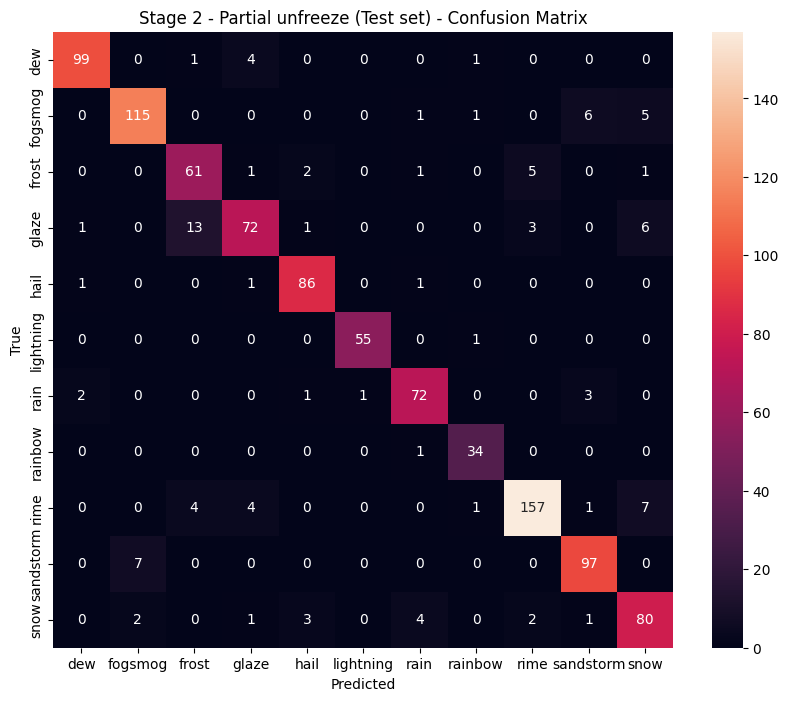

In [38]:
# TODO: evaluate Stage 2 on the test set
#   results_stage2 = evaluate_model(model_stage2, test_loader, CLASSES,
#                                    title="Stage 2 - Partial unfreeze (Test set)")
results_stage2 = evaluate_model(
    model_stage2,
    test_loader,
    CLASSES,
    title="Stage 2 - Partial unfreeze (Test set)"
)

## 12. TODO — Stage 3: Full fine-tuning with differential learning rates

Unfreeze the entire network. Set up an optimizer with one parameter group **per stage group** in
`model.features` (or at least group them sensibly, e.g. `features[0:3]`, `features[3:6]`,
`features[6:9]`, `classifier`), with learning rates increasing from the earliest groups (small —
these are general, don't disturb them much) to the latest groups and classifier (larger — these
should adapt the most). Add an `lr_scheduler.StepLR` on top, same as lecture.

Again, **experiment**: try shifting the whole learning-rate range up or down, or changing how
many groups you split the network into, and note the effect in the discussion cell.

Store the trained model as `model_stage3` and its history as `history_stage3`.


[Stage 3 - Full fine-tuning] Epoch 1/5
----------------------------------------
train | loss: 0.9723  acc: 0.7724
val   | loss: 0.3991  acc: 0.8630

[Stage 3 - Full fine-tuning] Epoch 2/5
----------------------------------------
train | loss: 0.3482  acc: 0.8720
val   | loss: 0.2831  acc: 0.9038

[Stage 3 - Full fine-tuning] Epoch 3/5
----------------------------------------
train | loss: 0.2647  acc: 0.9055
val   | loss: 0.2819  acc: 0.8941

[Stage 3 - Full fine-tuning] Epoch 4/5
----------------------------------------
train | loss: 0.2446  acc: 0.9151
val   | loss: 0.2707  acc: 0.8989

[Stage 3 - Full fine-tuning] Epoch 5/5
----------------------------------------
train | loss: 0.2499  acc: 0.9092
val   | loss: 0.2913  acc: 0.8980

[Stage 3 - Full fine-tuning] Training complete in 3m 43s
[Stage 3 - Full fine-tuning] Best validation accuracy: 0.9038


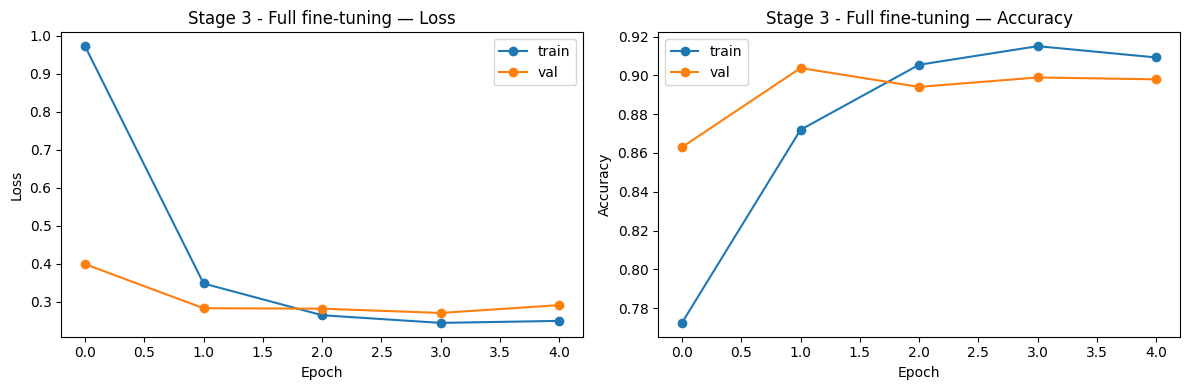

In [39]:
# TODO: Stage 3 - full fine-tuning
#   1. model_stage3 = build_efficientnet_b1(NUM_CLASSES, pretrained=True)
#   2. unfreeze every parameter (requires_grad = True for all)
#   3. model_stage3 = model_stage3.to(device)
#   4. optimizer_stage3 = optim.Adam([
#          {"params": <early features groups>, "lr": <tiny LR, e.g. 1e-6>},
#          {"params": <middle features groups>, "lr": <small LR, e.g. 1e-5>},
#          {"params": <late features groups>,  "lr": <medium LR, e.g. 5e-5>},
#          {"params": model_stage3.classifier.parameters(), "lr": <largest LR, e.g. 1e-3>},
#      ])
#   5. scheduler_stage3 = lr_scheduler.StepLR(optimizer_stage3, step_size=<your choice>, gamma=<your choice>)
#   6. EPOCHS_STAGE3 = <your choice>
#   7. model_stage3, history_stage3 = train_model(..., scheduler=scheduler_stage3, ...)
#   8. plot_history(history_stage3, "Stage 3 - Full fine-tuning")
# Stage 3 - Full fine-tuning

model_stage3 = build_efficientnet_b1(NUM_CLASSES, pretrained=True)

# Unfreeze all parameters
for param in model_stage3.parameters():
    param.requires_grad = True

model_stage3 = model_stage3.to(device)

optimizer_stage3 = optim.Adam([
    {
        "params": model_stage3.features[0:3].parameters(),
        "lr": 1e-6
    },
    {
        "params": model_stage3.features[3:6].parameters(),
        "lr": 1e-5
    },
    {
        "params": model_stage3.features[6:9].parameters(),
        "lr": 5e-5
    },
    {
        "params": model_stage3.classifier.parameters(),
        "lr": 1e-3
    }
])

scheduler_stage3 = lr_scheduler.StepLR(
    optimizer_stage3,
    step_size=2,
    gamma=0.1
)

EPOCHS_STAGE3 = 5

model_stage3, history_stage3 = train_model(
    model_stage3,
    dataloaders,
    dataset_sizes,
    criterion,
    optimizer_stage3,
    scheduler=scheduler_stage3,
    num_epochs=EPOCHS_STAGE3,
    stage_name="Stage 3 - Full fine-tuning"
)

plot_history(
    history_stage3,
    "Stage 3 - Full fine-tuning"
)

Stage 3 - Full fine-tune (Test set)
Accuracy:  0.9204
Precision: 0.9235
Recall:    0.9243
F1-score:  0.9233

Classification Report:
              precision    recall  f1-score   support

         dew       0.97      0.97      0.97       105
     fogsmog       0.91      0.90      0.91       128
       frost       0.85      0.90      0.88        71
       glaze       0.89      0.79      0.84        96
        hail       0.97      0.99      0.98        89
   lightning       1.00      0.98      0.99        56
        rain       0.90      0.96      0.93        79
     rainbow       0.94      0.94      0.94        35
        rime       0.92      0.93      0.92       174
   sandstorm       0.94      0.89      0.92       104
        snow       0.86      0.90      0.88        93

    accuracy                           0.92      1030
   macro avg       0.92      0.92      0.92      1030
weighted avg       0.92      0.92      0.92      1030



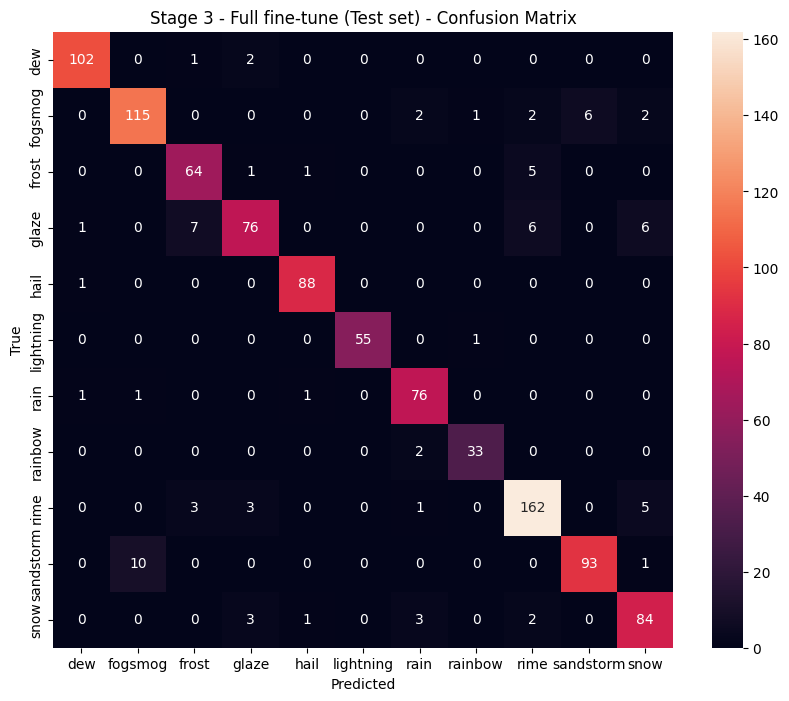

In [40]:
# TODO: evaluate Stage 3 on the test set
#   results_stage3 = evaluate_model(model_stage3, test_loader, CLASSES,
#                                    title="Stage 3 - Full fine-tune (Test set)")
results_stage3 = evaluate_model(
    model_stage3,
    test_loader,
    CLASSES,
    title="Stage 3 - Full fine-tune (Test set)"
)

## 13. Comparing all three strategies (provided)

Once `results_stage1`, `results_stage2`, and `results_stage3` exist (each a dict with
`accuracy`/`precision`/`recall`/`f1`), this cell builds the same comparison table and bar chart
as lecture. Nothing to change here — just make sure your three stages above produce
correctly-named results dicts.

,accuracy,precision,recall,f1
Stage,,,,
1. Head only,0.8913,0.8890,0.8984,0.8929
2. Partial unfreeze,0.9010,0.8978,0.9070,0.9015
3. Full fine-tune,0.9204,0.9235,0.9243,0.9233


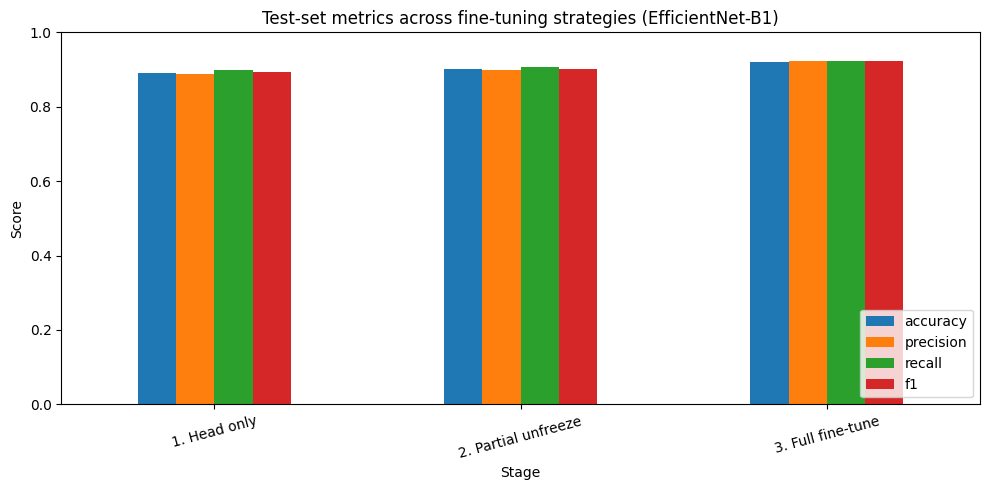

In [41]:
comparison_df = pd.DataFrame([
    {"Stage": "1. Head only", **results_stage1},
    {"Stage": "2. Partial unfreeze", **results_stage2},
    {"Stage": "3. Full fine-tune", **results_stage3},
]).set_index("Stage")

display(comparison_df.style.format("{:.4f}").background_gradient(cmap="Greens"))

comparison_df.plot(kind="bar", figsize=(10, 5), rot=15)
plt.title("Test-set metrics across fine-tuning strategies (EfficientNet-B1)")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


## 14. Discussion — fill this in

Answer the following in a few sentences each. Be specific — refer to actual numbers/plots you
produced above.

**1. Learning rate experiments.** List at least two different learning-rate configurations you
tried for Stage 2 and/or Stage 3 (backbone LR, head LR, and any scheduler settings). For each,
report the resulting validation/test accuracy. What happened when the backbone learning rate was
too high? Too low?

*(I tested two learning-rate configurations for Stage 2. The first used a backbone learning rate of 1e-5 and a classifier learning rate of 1e-3, which achieved a test accuracy of 90.10%. The second used a higher backbone learning rate of 1e-4 and a classifier learning rate of 5e-4, which improved the test accuracy to 91.36%. This suggests that the original backbone learning rate was slightly too low, while increasing it allowed the pretrained features to adapt better to the weather dataset. However, the backbone learning rate should still remain relatively small to avoid significantly changing the useful pretrained ImageNet features.)*

**2. Best strategy for this dataset.** Which of the three stages performed best on the test set?
Was the difference large or small? Why do you think that is, given the size of the dataset and
how similar weather photos are to natural ImageNet images?

*(Stage 3 performed best with 92.04% accuracy, compared with 90.10% for Stage 2 and 89.13% for Stage 1. The improvement was small because the pretrained ImageNet features were already useful, but full fine-tuning helped the model adapt better to the weather images.)*

**3. ResNet-34 vs. EfficientNet-B1.** Compare your EfficientNet-B1 results to the ResNet-34
results from the lecture notebook (same dataset, same splits). Which architecture performed
better, and by how much? Did one architecture benefit more from fine-tuning than the other?

*(your answer here)*

**4. Per-class performance.** Look at the confusion matrices / classification reports from your
best-performing stage. Which classes does the model struggle with most? Is this related to the
class imbalance you observed in Section 3, to visual similarity between certain weather
conditions, or something else?

*(The model struggled most with glaze, frost, and snow because they look quite similar. Class imbalance may also have had some effect.)*



[Stage 2 - LR Experiment 2] Epoch 1/5
----------------------------------------
train | loss: 1.1823  acc: 0.7204
val   | loss: 0.4961  acc: 0.8435

[Stage 2 - LR Experiment 2] Epoch 2/5
----------------------------------------
train | loss: 0.4254  acc: 0.8620
val   | loss: 0.3463  acc: 0.8834

[Stage 2 - LR Experiment 2] Epoch 3/5
----------------------------------------
train | loss: 0.3301  acc: 0.8797
val   | loss: 0.3105  acc: 0.8921

[Stage 2 - LR Experiment 2] Epoch 4/5
----------------------------------------
train | loss: 0.2792  acc: 0.8986
val   | loss: 0.2941  acc: 0.8921

[Stage 2 - LR Experiment 2] Epoch 5/5
----------------------------------------
train | loss: 0.2406  acc: 0.9128
val   | loss: 0.2894  acc: 0.8873

[Stage 2 - LR Experiment 2] Training complete in 2m 53s
[Stage 2 - LR Experiment 2] Best validation accuracy: 0.8921


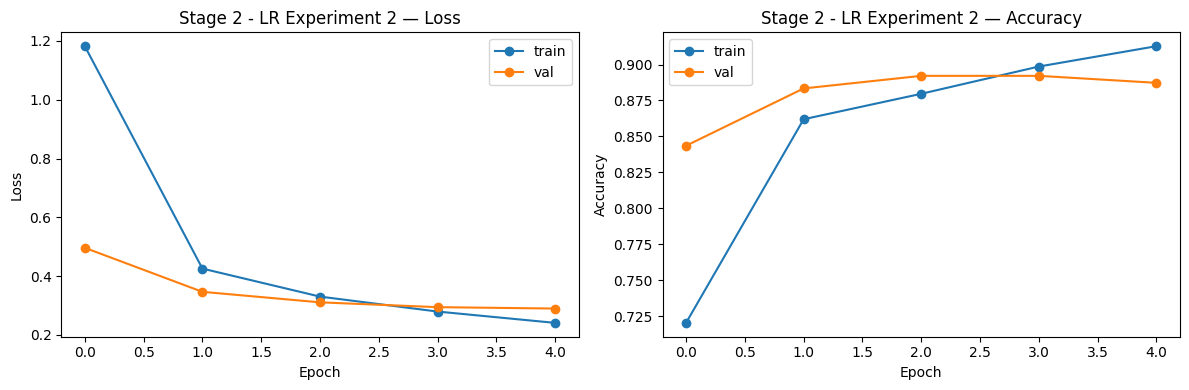

In [42]:
# Stage 2 - Learning Rate Experiment 2

model_stage2_exp2 = build_efficientnet_b1(NUM_CLASSES, pretrained=True)

# Freeze everything
for param in model_stage2_exp2.parameters():
    param.requires_grad = False

# Unfreeze features[7]
for param in model_stage2_exp2.features[7].parameters():
    param.requires_grad = True

# Unfreeze features[8]
for param in model_stage2_exp2.features[8].parameters():
    param.requires_grad = True

# Unfreeze classifier
for param in model_stage2_exp2.classifier.parameters():
    param.requires_grad = True

model_stage2_exp2 = model_stage2_exp2.to(device)

optimizer_stage2_exp2 = optim.Adam([
    {
        "params": list(model_stage2_exp2.features[7].parameters()) +
                  list(model_stage2_exp2.features[8].parameters()),
        "lr": 1e-4
    },
    {
        "params": model_stage2_exp2.classifier.parameters(),
        "lr": 5e-4
    }
])

model_stage2_exp2, history_stage2_exp2 = train_model(
    model_stage2_exp2,
    dataloaders,
    dataset_sizes,
    criterion,
    optimizer_stage2_exp2,
    scheduler=None,
    num_epochs=5,
    stage_name="Stage 2 - LR Experiment 2"
)

plot_history(
    history_stage2_exp2,
    "Stage 2 - LR Experiment 2"
)

Stage 2 - LR Experiment 2 (Test set)
Accuracy:  0.9136
Precision: 0.9158
Recall:    0.9189
F1-score:  0.9166

Classification Report:
              precision    recall  f1-score   support

         dew       0.97      0.96      0.97       105
     fogsmog       0.92      0.91      0.91       128
       frost       0.83      0.89      0.86        71
       glaze       0.89      0.78      0.83        96
        hail       0.93      0.98      0.95        89
   lightning       0.98      0.98      0.98        56
        rain       0.91      0.91      0.91        79
     rainbow       0.97      0.97      0.97        35
        rime       0.94      0.91      0.93       174
   sandstorm       0.93      0.93      0.93       104
        snow       0.80      0.88      0.84        93

    accuracy                           0.91      1030
   macro avg       0.92      0.92      0.92      1030
weighted avg       0.92      0.91      0.91      1030



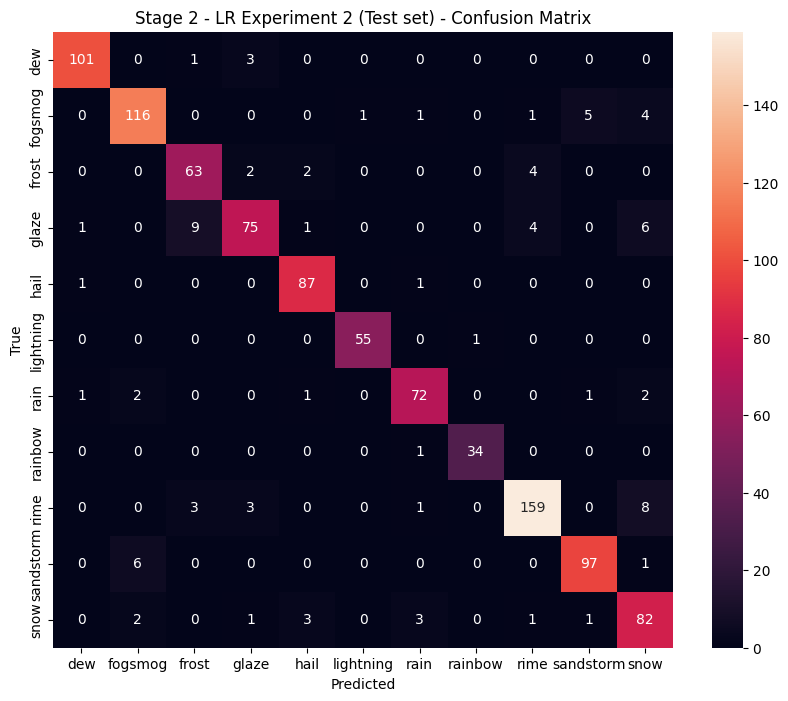

In [43]:
results_stage2_exp2 = evaluate_model(
    model_stage2_exp2,
    test_loader,
    CLASSES,
    title="Stage 2 - LR Experiment 2 (Test set)"
)

In [44]:
print("Original Stage 2:", results_stage2)
print("Stage 2 Experiment 2:", results_stage2_exp2)

Original Stage 2: {'accuracy': 0.9009708737864077, 'precision': 0.8978332527624061, 'recall': 0.9069919775392045, 'f1': 0.9014579920813343}
Stage 2 Experiment 2: {'accuracy': 0.9135922330097087, 'precision': 0.9157932946826218, 'recall': 0.9188569518488368, 'f1': 0.9166084912946336}
